#Problem Statement

The given dataset is property database.

Select 4 to 5 columns as independent variables (input features) from the following:

Square_Footage

Num_Bedrooms

Num_Bathrooms

Year_Built

Lot_Size

Choose one column as the dependent variable (target), such as:

Price

#Deliverables:
Implement multiple Linear Regression models using different combinations of the input features.

Compare the R-squared values of each model to evaluate prediction performance.

In [4]:
!pip install pyspark

In [45]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt


In [34]:
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [35]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")


Spark UI available at: http://b30035364669:4040


In [36]:
spark.sparkContext.setLogLevel("INFO")

In [37]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")


CPU Usage: 36.9%
Memory Usage: 19.3%


In [38]:
df = spark.read.csv("/content/property.csv", header=True, inferSchema=True)

df.show()

print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())


+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [39]:
df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [40]:
df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [41]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 36.1%
Memory Usage after csv file: 19.3%


In [42]:
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [46]:
train_data, test_data = df.randomSplit([0.7,0.3], seed=42)

In [48]:
# Evaluation Metrics

mse_eval = RegressionEvaluator(
    labelCol="Price",
    predictionCol="prediction",
    metricName="mse"
)

rmse_eval = RegressionEvaluator(
    labelCol="Price",
    predictionCol="prediction",
    metricName="rmse"
)

r2_eval = RegressionEvaluator(
    labelCol="Price",
    predictionCol="prediction",
    metricName="r2"
)

In [51]:
# Different Feature Combinations

feature_sets = {

    "Model 1":
    ["Square_Footage"],

    "Model 2":
    ["Square_Footage",
     "Num_Bedrooms"],

    "Model 3":
    ["Square_Footage",
     "Num_Bedrooms",
     "Num_Bathrooms"],

    "Model 4":
    ["Square_Footage",
     "Num_Bedrooms",
     "Num_Bathrooms",
     "Lot_Size"],

    "Model 5":
    ["Square_Footage",
     "Num_Bedrooms",
     "Num_Bathrooms",
     "Year_Built",
     "Lot_Size"]

}

results=[]


In [52]:
# Train Different Linear Regression Models

for model_name,features in feature_sets.items():

    print("="*60)
    print(model_name)
    print("Features Used:",features)

    assembler = VectorAssembler(
        inputCols=features,
        outputCol="Features"
    )

    scaler = StandardScaler(
        inputCol="Features",
        outputCol="scaled_Features"
    )

    lr = LinearRegression(
        labelCol="Price",
        featuresCol="scaled_Features"
    )

    pipeline = Pipeline(
        stages=[
            assembler,
            scaler,
            lr
        ]
    )

    model = pipeline.fit(train_data)

    prediction = model.transform(test_data)

    mse = mse_eval.evaluate(prediction)
    rmse = rmse_eval.evaluate(prediction)
    r2 = r2_eval.evaluate(prediction)

    print("Coefficients:",model.stages[-1].coefficients)
    print("Intercept:",model.stages[-1].intercept)

    print("MSE :",mse)
    print("RMSE:",rmse)
    print("R2 :",r2)

    results.append([
        model_name,
        ", ".join(features),
        mse,
        rmse,
        r2
    ])


Model 1
Features Used: ['Square_Footage']
Coefficients: [259792.35831633888]
Intercept: 31691.37669000907
MSE : 495899628.2822505
RMSE: 22268.803925721975
R2 : 0.9926949578327512
Model 2
Features Used: ['Square_Footage', 'Num_Bedrooms']
Coefficients: [259779.3914304116,8528.650616276367]
Intercept: 14239.469221427671
MSE : 424336885.90910596
RMSE: 20599.4389707367
R2 : 0.993749140616575
Model 3
Features Used: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms']
Coefficients: [259773.45858583352,8531.599825901285,3373.82006746858]
Intercept: 6697.041259339497
MSE : 412806811.19598633
RMSE: 20317.647777141585
R2 : 0.9939189888624038
Model 4
Features Used: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size']
Coefficients: [259772.49181466084,8531.444580642483,3373.571561674841,272.19138828927424]
Intercept: 6123.840215934645
MSE : 412734117.9162165
RMSE: 20315.858778703314
R2 : 0.993920059699008
Model 5
Features Used: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Bui

In [53]:
# Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Features",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

print("\nComparison of Models\n")
print(results_df)


Comparison of Models

     Model                                           Features           MSE  \
0  Model 1                                     Square_Footage  4.958996e+08   
1  Model 2                       Square_Footage, Num_Bedrooms  4.243369e+08   
2  Model 3        Square_Footage, Num_Bedrooms, Num_Bathrooms  4.128068e+08   
3  Model 4  Square_Footage, Num_Bedrooms, Num_Bathrooms, L...  4.127341e+08   
4  Model 5  Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...  4.002798e+08   

           RMSE  R2 Score  
0  22268.803926  0.992695  
1  20599.438971  0.993749  
2  20317.647777  0.993919  
3  20315.858779  0.993920  
4  20006.993408  0.994104  


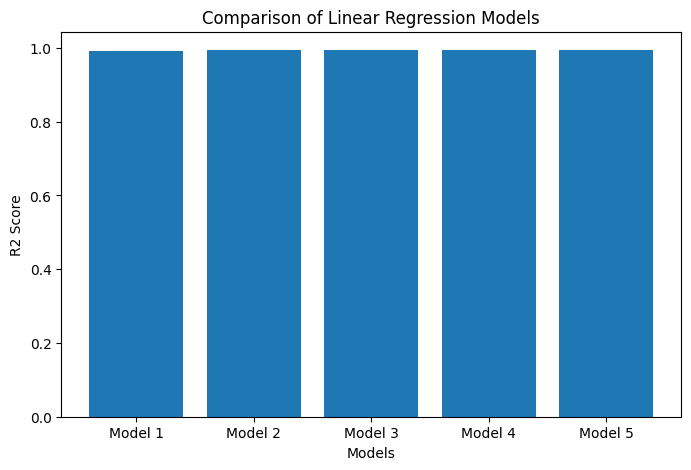

In [54]:
# Plot R2 Scores

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Comparison of Linear Regression Models")

plt.show()


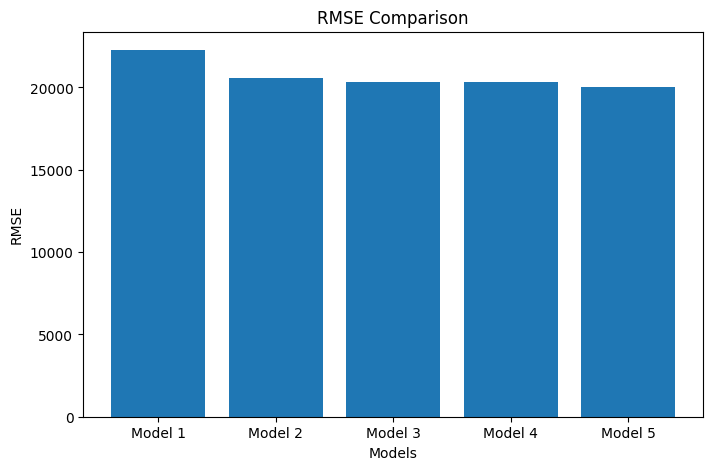

In [55]:
# Plot RMSE

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.show()

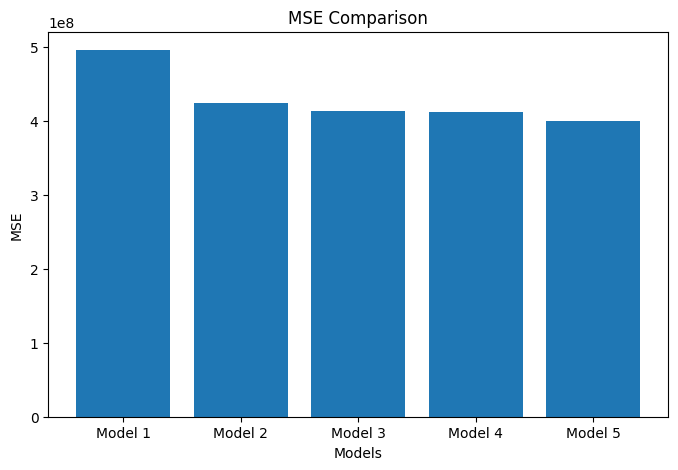

In [56]:
# Plot MSE

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["MSE"]
)

plt.xlabel("Models")
plt.ylabel("MSE")
plt.title("MSE Comparison")

plt.show()

In [57]:
# Best Model

best = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("\nBest Model Based on R2 Score\n")
print(best)


Best Model Based on R2 Score

Model                                                 Model 5
Features    Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...
MSE                                          400279785.232239
RMSE                                             20006.993408
R2 Score                                             0.994104
Name: 4, dtype: object


In [58]:
# Stop Spark

spark.stop()